# ***Title : Heart Diseases Pediction***
### ***Author :*** [***`Fawad Ali Shaikh`***](https://www.kaggle.com/fawadalishaikh)
### ***Date :***   ***`22.Mar.2024`***
### ***Dataset :***  [***`UCI Heart Disease`***](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?select=heart_disease_uci.csv)


## ***Meta-Data***
## ***`Context:`***
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

## ***`Content:`***
#### ***Column Descriptions:***
* `id` (Unique id for each patient)
*`age` (Age of the patient in years)
*`origin` (place of study)
*`sex` (Male/Female)
*`cp` chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
*`trestbps` resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
*`chol` (serum cholesterol in mg/dl)
*`fbs` (if fasting blood sugar > 120 mg/dl)
*`restecg` (resting electrocardiographic results)
*--`Values:` [normal, stt abnormality, lv hypertrophy]
*`thalach`: maximum heart rate achieved
*`exang:` exercise-induced angina (True/ False)
*`oldpeak:` ST depression induced by exercise relative to rest
*`slope:` the slope of the peak exercise ST segment
*`ca:` number of major vessels (0-3) colored by fluoroscopy
*`thal:` [normal; fixed defect; reversible defect]
*`num:` the predicted attribute
## ***`Acknowledgements`***
#### ***Creators:***
*Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
*University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
*University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
*V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
##***`Relevant Papers:`***
Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
Web Link
David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." Web Link
Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61. Web Link
##***`Citation Request:`***
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. They would be:

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
*University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
*University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
*V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

### ***Import libraries***
***First, we import libraries***

In [ ]:
# to handle data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# to preprocess data

from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning tasks
from sklearn.model_selection import cross_val_score,train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')




### ***Load Dataset***

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/gdrive/MyDrive/Kaggle'

In [ ]:
cd gdrive/MyDrive/Kaggle

In [ ]:
!kaggle datasets download -d redwankarimsony/heart-disease-data

In [ ]:
!unzip heart-disease-data.zip -d heart-disease-data

In [ ]:
cd heart-disease-data

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')

In [ ]:
df.head()

## ***Exploratory Data Analysis (EDA)***


In [ ]:
# Let's check the datatype of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# Let's check shape of the dataset
df.shape

(920, 16)

In [ ]:
# Let's describe age
df['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

In [ ]:
# minimum & maximum age
df['age'].min(),df['age'].max()

(28, 77)

<Axes: xlabel='age', ylabel='Count'>

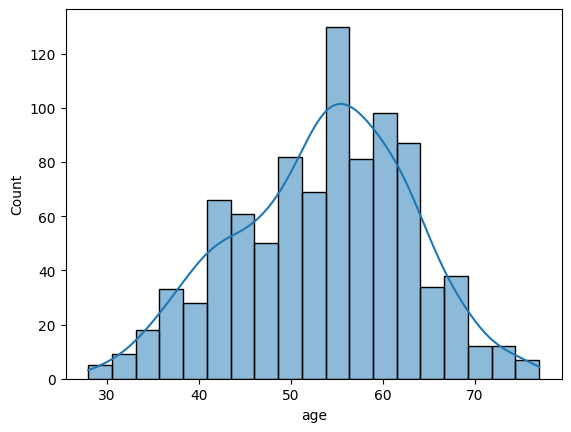

In [ ]:
# Use Histogram to know from what age heart attack most occured
sns.histplot(df['age'], kde=True)

Mean 53.51086956521739
Median 54.0
Mode 0    54
Name: age, dtype: int64


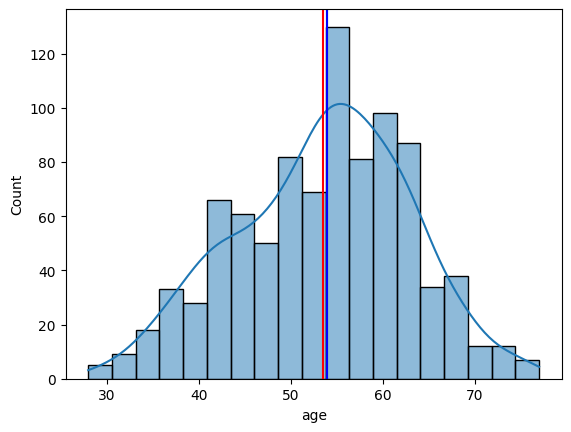

In [ ]:
# plot the mean, median & mode of age
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(),color='red')
plt.axvline(df['age'].median(),color='green')
plt.axvline(df['age'].mode()[0],color='blue')

# print the values of mean, median & mode
print('Mean',df['age'].mean())
print('Median',df['age'].median())
print('Mode',df['age'].mode())



In [ ]:
# Let's make histogram on age using plotly & color based on sex
fig = px.histogram(data_frame=df,x='age',color='sex')
fig.show()

In [ ]:
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [ ]:
# Calculate percentages of male & females
male_count = 726
female_count = 194
total_count = male_count + female_count

# Calculate percentage
male_percentages = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

# display the result
print(f"Male percentage in data : {male_percentages:.2f}")
print(f"Female percentage in data : {female_percentages:.2f}")

# difference
difference_percentage = ((male_count - female_count) / female_count) * 100
print(f"Males are {difference_percentage:.2f}% more than females in the data.")


Male percentage in data : 78.91
Female percentage in data : 21.09
Males are 274.23% more than females in the data.


In [ ]:
# find the value count of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        48      9
        43      9
               ..
Male    77      2
        76      1
        33      1
        28      1
        31      1
Name: count, Length: 91, dtype: int64

***Let's deal with dataset column***

In [ ]:
# Unique values in dataset column
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [ ]:
# Value counts of dataset column
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [ ]:
# make plot using plotly
fig = px.bar(data_frame=df,x='dataset',color='sex')
fig.show()

# print the values count of dataset column based on sex
print(df.groupby('sex')['dataset'].value_counts())

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64


In [ ]:
# Let's make histogram on age using plotly & color based on dataset
fig = px.histogram(data_frame=df,x='age',color='dataset')
fig.show()

# print the values of mean, median & mode
print(f"Mean of the dataset :,{df.groupby('dataset')['age'].mean()}")
print('--------------')
print(f"Median of the dataset :,{df.groupby('dataset')['age'].median()}")
print('--------------')
print(f"Mode of the dataset :,{df.groupby('dataset')['age'].agg(pd.Series.mode)}")



Mean of the dataset :,dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64
--------------
Median of the dataset :,dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64
--------------
Mode of the dataset :,dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object


 ***Let's deal with cp (Chest Pain) column***

In [ ]:
# Unique values in cp column
df['cp'].unique()


array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [ ]:
# Count values in cp column
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [ ]:
# Let's make histogram on age using plotly & color based on cp
fig = px.histogram(data_frame=df,x='age',color='cp')
fig.show()

# print the values of mean, median & mode
print(f"Mean of the cp :,{df.groupby('cp')['age'].mean()}")
print('--------------')
print(f"Median of the cp :,{df.groupby('cp')['age'].median()}")
print('--------------')
print(f"Mode of the cp :,{df.groupby('cp')['age'].agg(pd.Series.mode)}")

Mean of the cp :,cp
asymptomatic       54.959677
atypical angina    49.241379
non-anginal        53.333333
typical angina     54.826087
Name: age, dtype: float64
--------------
Median of the cp :,cp
asymptomatic       56.0
atypical angina    50.5
non-anginal        53.5
typical angina     59.0
Name: age, dtype: float64
--------------
Mode of the cp :,cp
asymptomatic             57
atypical angina          54
non-anginal        [51, 54]
typical angina           62
Name: age, dtype: object


<Axes: xlabel='cp', ylabel='Count'>

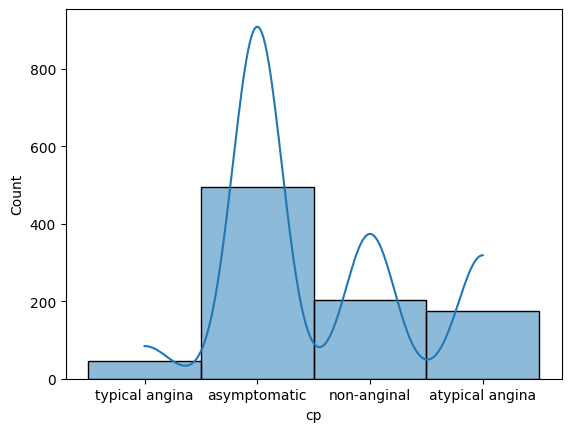

In [ ]:
# plot the mean, median & mode of age
sns.histplot(df['cp'], kde=True)


### ***Let's deal with trestbps (resting blood pressure) column***

In [ ]:
# First we check missing values in trestbps column
df['trestbps'].isnull().sum()

59

In [ ]:
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

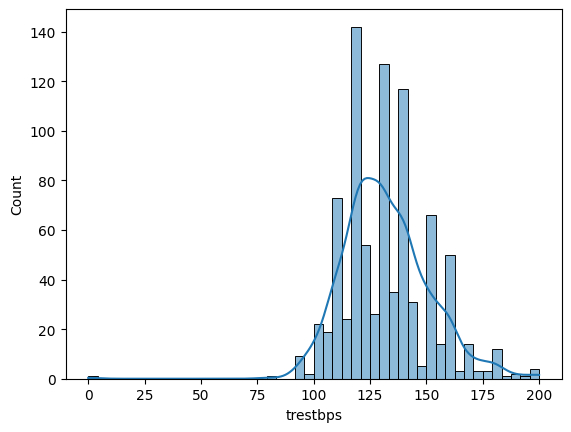

In [ ]:
# create histplot
sns.histplot(df,x='trestbps',kde=True)

### ***Impute Missing values using Iterative Imputer (dtype : Float)***

In [ ]:
# Impute missing values in trestbps column with iterative imputer
imputer = IterativeImputer(max_iter=10,random_state=42)

imputer.fit(df[['trestbps']])

df['trestbps']= imputer.transform(df[['trestbps']])

print('Missing values : ',df['trestbps'].isnull().sum())



Missing values :  0


In [ ]:
#Let's Impute missing values in other columns
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     0.000000
num          0.000000
dtype: float64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# Impute missing values in ca, oldpeak ,thalch, chol column with iterative imputer
imputer2 = IterativeImputer(max_iter=10,random_state=42)

df[['ca', 'thalch', 'chol', 'oldpeak']]= imputer2.fit_transform(df[['ca', 'thalch','chol', 'oldpeak']])

print('Missing values :\n',df[['ca', 'thalch', 'chol', 'oldpeak']].isnull().sum())

Missing values :
 ca         0
thalch     0
chol       0
oldpeak    0
dtype: int64


### ***Impute Missing values using ML Models (dtype : object)***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        920 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# Let's make a object having all missing values columns
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_values  = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
missing_values


['fbs', 'restecg', 'exang', 'slope', 'thal']

In [ ]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [ ]:
# define the function to impute the missing values in thal column
'''
def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)*\
    y = df_not_null[passed_col]


    other_missing_cols = [col for col in missing_values if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

# For continuous (integers) missing values


#def impute_continuous_missing_data(passed_col):

   # df_null = df[df[passed_col].isnull()]
    #df_not_null = df[df[passed_col].notnull()]

    #X = df_not_null.drop(passed_col, axis=1)
    #y = df_not_null[passed_col]

    #other_missing_cols = [col for col in missing_values if col != passed_col]

    #label_encoder = LabelEncoder()

    #for col in X.columns:
     #   if X[col].dtype == 'object' or X[col].dtype == 'category':
      #      X[col] = label_encoder.fit_transform(X[col])

    #iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    #for col in other_missing_cols:
     #   if X[col].isnull().sum() > 0:
      #      col_with_missing_values = X[col].values.reshape(-1, 1)
       #     imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
        #    X[col] = imputed_values[:, 0]
        #else:
         #   pass

   # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #rf_regressor = RandomForestRegressor()

    #rf_regressor.fit(X_train, y_train)

    #y_pred = rf_regressor.predict(X_test)

    #print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    #print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
    #print("R2 =", r2_score(y_test, y_pred), "\n")

    #X = df_null.drop(passed_col, axis=1)

    #for col in X.columns:
     #   if X[col].dtype == 'object' or X[col].dtype == 'category':
      #      X[col] = label_encoder.fit_transform(X[col])

   # for col in other_missing_cols:
    #    if X[col].isnull().sum() > 0:
     #       col_with_missing_values = X[col].values.reshape(-1, 1)
      #      imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
       #     X[col] = imputed_values[:, 0]
       # else:
        #    pass

    #if len(df_null) > 0:
     #   df_null[passed_col] = rf_regressor.predict(X)
    #else:
     #   pass

    #df_combined = pd.concat([df_not_null, df_null])

    #return df_combined[passed_col]
    '''

In [ ]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

thal        52.826087
slope       33.586957
fbs          9.782609
exang        5.978261
restecg      0.217391
id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     0.000000
chol         0.000000
thalch       0.000000
oldpeak      0.000000
ca           0.000000
num          0.000000
dtype: float64

In [ ]:
# remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_values:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    #elif col in numeric_cols:
     #   df[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 79.52 accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 64.67 accuracy

Missing Values exang : 5.98%
The feature 'exang' has been imputed with 77.46 accuracy

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 67.48 accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 77.01 accuracy



In [ ]:
#Let's Impute missing values in other columns
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

### ***So, all missing values are imputed***

---

## ***Let's deal with Outlier***

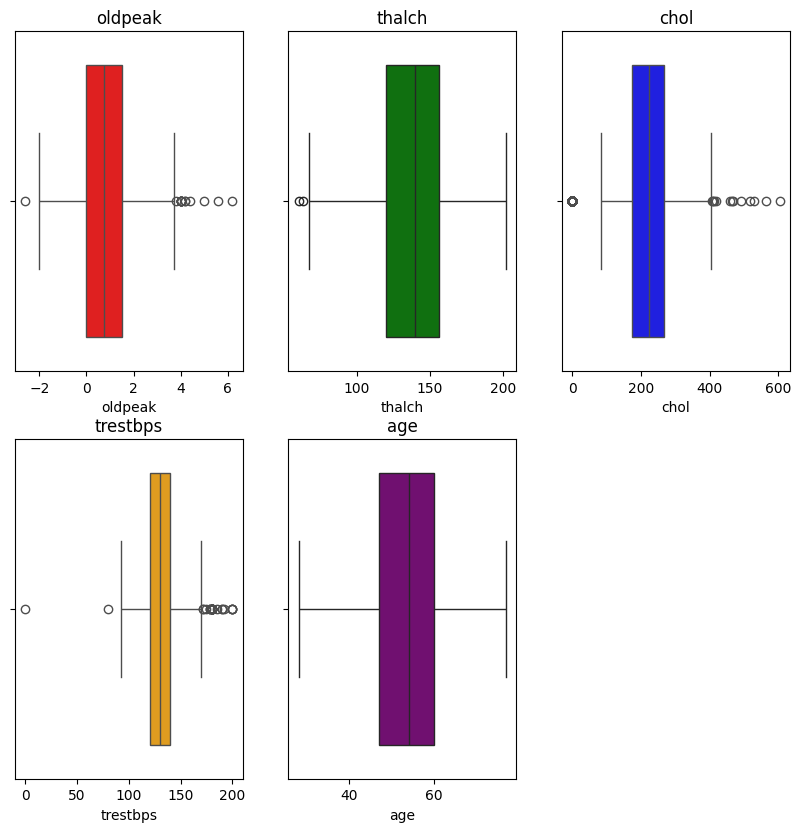

In [ ]:
plt.figure(figsize=(10,15))
colors = ['red','green','blue','orange','purple']

for i ,col in enumerate(numeric_cols):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=df[col], color = colors[i])
  plt.title(col)
plt.show()


In [ ]:
# make plot of outliers using plotly
fig = px.box(data_frame=df , y='trestbps')
fig.show()

fig = px.box(data_frame=df , y='chol')
fig.show()

fig = px.box(data_frame=df , y='thalch')
fig.show()

fig = px.box(data_frame=df , y='oldpeak')
fig.show()

fig = px.box(data_frame=df , y='age')
fig.show()

In [ ]:
# row where 'trestps' is 0
df[df['trestbps']==0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
753,754,55,Male,VA Long Beach,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,0.438714,reversable defect,3


In [ ]:
# remove this row
df[df['trestbps'] !=0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.000000,233.0,True,lv hypertrophy,150.000000,False,2.300000,downsloping,0.000000,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.000000,286.0,False,lv hypertrophy,108.000000,True,1.500000,flat,3.000000,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.000000,229.0,False,lv hypertrophy,129.000000,True,2.600000,flat,2.000000,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.000000,250.0,False,normal,187.000000,False,3.500000,downsloping,0.000000,normal,0
4,5,41,Female,Cleveland,atypical angina,130.000000,204.0,False,lv hypertrophy,172.000000,False,1.400000,upsloping,0.000000,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.000000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,0.589884,normal,1
916,917,62,Male,VA Long Beach,typical angina,132.132404,139.0,False,st-t abnormality,134.118760,False,0.850348,flat,0.679751,fixed defect,0
917,918,55,Male,VA Long Beach,asymptomatic,122.000000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,0.957746,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,132.132404,385.0,True,lv hypertrophy,148.111261,True,0.965463,flat,0.815466,reversable defect,0


---

## ***Machine Learninig***

In [ ]:
# columns
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
# deal with 'num' column
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

The Target Column is `num` which is the predicted attribute. We will use this column to predict the heart disease. The unique values in this column are: [0, 1, 2, 3, 4], which states that there are 5 types of heart diseases.

0 = no heart disease\
1 = mild heart disease\
2 = moderate heart disease \
3 = severe heart disease\
4 = critical heart disease

In [ ]:
# split data into X & y
X = df.drop('num',axis=1)
y = df['num']

# encode X data using separate label encoder for all categorical columns and save it for inverse transform
# Task: Separate Encoder for all cat and object columns and inverse transform at the end

label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass


# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Models that you will use to predict the heart disease. These models should be classifiers for multi-class classification.

1. logistic regression
2. KNN
3. NB
4. SVM
5. Decision Tree
6. Random Forest
7. XGBoost
8. GradientBoosting
9. AdaBoost
10. lightGBM

In [ ]:
# import all models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# from lightgbm import LGBMClassifier

# impot pipeline
from sklearn.pipeline import Pipeline

# import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Ada Boost', AdaBoostClassifier(random_state=42)),
    ('XG Boost', XGBClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        # ('imputer', SimpleImputer(strategy='most_frequent')),
        # ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('model', model)
    ])

    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)

    # Calculate mean accuracy
    mean_accuracy = scores.mean()

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Print the performance metrics
    print("Model:", name)
    print("Cross-validation Accuracy:", mean_accuracy)
    print("Test Accuracy:", accuracy)
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the best model
print("Best Model:", best_model)

# save the best model
import pickle
pickle.dump(best_model, open('heart_disease_model.pkl', 'wb'))

Model: Random Forest
Cross-validation Accuracy: 0.645311638168781
Test Accuracy: 0.5978260869565217

Model: Gradient Boosting
Cross-validation Accuracy: 0.6303640375068946
Test Accuracy: 0.5978260869565217

Model: Support Vector Machine
Cross-validation Accuracy: 0.5950818165103879
Test Accuracy: 0.5597826086956522

Model: Logistic Regression
Cross-validation Accuracy: 0.5189924618496047
Test Accuracy: 0.4945652173913043

Model: K-Nearest Neighbors
Cross-validation Accuracy: 0.6045964331678617
Test Accuracy: 0.5271739130434783

Model: Decision Tree
Cross-validation Accuracy: 0.5841790770362199
Test Accuracy: 0.5869565217391305

Model: Ada Boost
Cross-validation Accuracy: 0.5746736532450819
Test Accuracy: 0.5108695652173914

Model: XG Boost
Cross-validation Accuracy: 0.6221731936017652
Test Accuracy: 0.6304347826086957

Model: Naive Bayes
Cross-validation Accuracy: 0.5596892811178525
Test Accuracy: 0.5434782608695652

Best Model: Pipeline(steps=[('model',
                 XGBClassifier(

### ***Output :***
1. Minimum & Maximum age that suffered from heart attack.
2. Heat attack cooured mostly in the age of 53-54.
3. Males & Females at the age of 54-55 are mostly suffered from Heart attack
4. Male percentage in data : 78.91
5. Female percentage in data : 21.09
6. Males are 274.23% more than females in the data.
7. We have highest number of people that have affected from Heart attack are from Cleveland (304) & lowest from Switzerland (123)
  
  1. Highest number of males from Hungary (212) & lowest  from Switzerland (113)
  2. Highest number of females from Cleveland (97) & lowest  from VA Long Beach (6)
8. Mean, Median & Mode of places are different :\
   ***Cleveland*** :                      
   `Mean :` 54.351974 ,
   `Median :` 55.5 ,
   `Mode :` 58\
   ***Hungary :*** \
   `Mean :` 47.894198 ,
   `Median :` 49.0 ,
   `Mode :`54\
   ***Switzerland :***\
   `Mean :` 55.31 ,
   `Medain :` 56.0 ,
   `Mode :` 61\
   ***VA Long Beach :***\
   `Mean :`59.35  ,
   `Median :`60.0 ,
   `Mode :` [62, 63]
9. Most people that are suffered from cp are of type asymptomatic & least from typical angina.
10.We have remove row where `trestbps` is 0, which is a outlier.

